# 30-year station climate normals

The U.S. Climate Normals are NOAA's 30-year averages of station weather, the
baseline that "above normal" is measured against. NCEI computes them from
1991 to 2020 station records and publishes hourly, daily, monthly, and
annual or seasonal normals through its Access Data Service. One request
returns one CSV with a row per station and calendar period, with no year:
the rows describe a typical January, not a particular one.

This walkthrough pulls the monthly normal high, low, and precipitation at Will
Rogers World Airport in Oklahoma City. It needs `usdata[pandas]` and
matplotlib, downloads under 1 kB, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:58:03+00:00
usdata 0.26.0; pandas 3.0.6


## Select

The manifest names one station, three NCEI data-type codes, and
`period: monthly`. It has no dates: normals are averages, not observations, so
without a window the whole calendar year is requested. For `monthly`, `daily`,
and `hourly` normals a `start` and `end` pick a month-day window and the year
is ignored. `MLY-TMAX-NORMAL` and `MLY-TMIN-NORMAL` are the normal daily high
and low averaged over each month, and `MLY-PRCP-NORMAL` the normal monthly
total. `units: metric` asks for degrees Celsius and millimetres.

In [2]:
print(manifest.read_text())

name: okc-climate-normals
sources:
  - dataset: noaa:climate-normals
    variables: [MLY-TMAX-NORMAL, MLY-TMIN-NORMAL, MLY-PRCP-NORMAL]
    params:
      period: monthly
      stations: USW00013967
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. The request URL carries the
placeholder year 2020 that the adapter sends for a calendar window.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)
print("Asset time bounds:", item.asset.time.start.date(), "to", item.asset.time.end.date())

File: normals-monthly-1991-2020_01-01_12-31_75003fc400d9.csv
Bytes: 967
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=normals-monthly-1991-2020&stations=USW00013967&format=csv&units=metric&includeStationLocation=1&startDate=2020-01-01&endDate=2020-12-31&dataTypes=MLY-TMAX-NORMAL%2CMLY-TMIN-NORMAL%2CMLY-PRCP-NORMAL
Retrieved (UTC): 2026-09-24T05:58:04+00:00
Checksum: sha256:187e68af78e294fbe10e9b8209ca875e9eb0a68808628189b306187eea688d53
Asset time bounds: 1991-01-01 to 2020-12-31


## Open

The generic CSV reader returns a DataFrame with one row per calendar month.
`DATE` is the two-digit month, `01` to `12`, with no year; reading it as text
keeps the leading zero. The normal columns are named by their NCEI codes.
NCEI's CSV has no units row, so the units come from the request: degrees
Celsius for the temperatures and millimetres for precipitation. Each row
repeats the station's latitude, longitude, and elevation in metres.

In [4]:
normals = item.open_csv(dtype={"DATE": "string"})
columns = ["MLY-TMAX-NORMAL", "MLY-TMIN-NORMAL", "MLY-PRCP-NORMAL"]
station = normals.iloc[0]
print(f"{len(normals)} rows, months {normals['DATE'].iloc[0]} to {normals['DATE'].iloc[-1]}")
print(
    f"{station['STATION']} at {station['LATITUDE']}, {station['LONGITUDE']}, "
    f"elevation {station['ELEVATION']} m"
)
normals[["DATE", *columns]].head()

12 rows, months 01 to 12
USW00013967 at 35.3889, -97.6006, elevation 391.7 m


,DATE,MLY-TMAX-NORMAL,MLY-TMIN-NORMAL,MLY-PRCP-NORMAL
0,01,9.6,-2.8,33.5
1,02,12.1,-0.7,36.1
2,03,17.2,4.2,64.8
3,04,21.7,8.6,91.4
4,05,26.1,14.2,134.9


## A first look

The normal year at the airport: the band between the normal daily low and
high for each month, and the normal monthly precipitation below it.

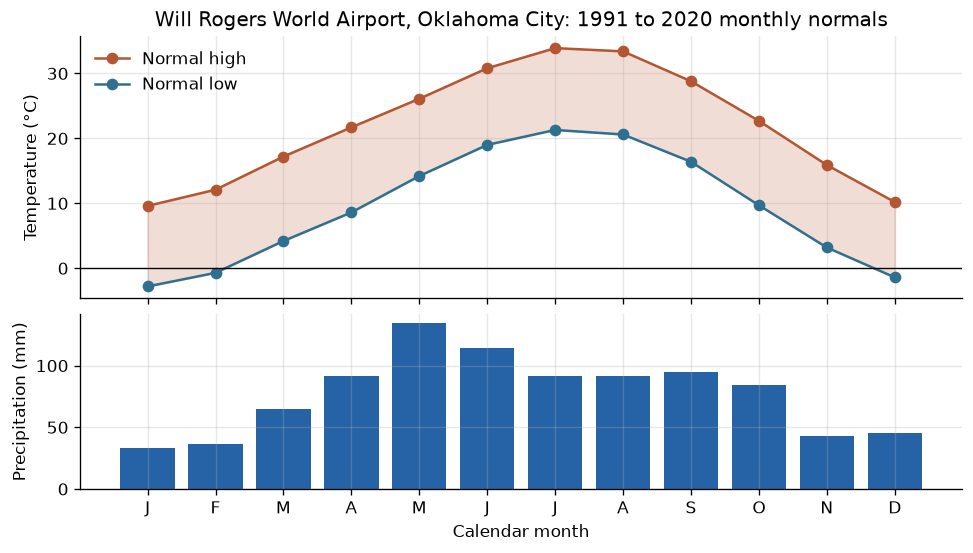

In [5]:
month = normals["DATE"].astype(int)
labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, (warm, wet) = plt.subplots(
    2, 1, sharex=True, layout="constrained", gridspec_kw={"height_ratios": [3, 2]}
)
warm.fill_between(
    month, normals["MLY-TMIN-NORMAL"], normals["MLY-TMAX-NORMAL"], color="#b45631", alpha=0.2
)
warm.plot(month, normals["MLY-TMAX-NORMAL"], marker="o", color="#b45631", label="Normal high")
warm.plot(month, normals["MLY-TMIN-NORMAL"], marker="o", color="#2f6f8f", label="Normal low")
warm.axhline(0, color="black", linewidth=0.8)
warm.set_ylabel("Temperature (°C)")
warm.set_title("Will Rogers World Airport, Oklahoma City: 1991 to 2020 monthly normals")
warm.legend(loc="upper left", frameon=False)
wet.bar(month, normals["MLY-PRCP-NORMAL"], color="#2563a6")
wet.set_ylabel("Precipitation (mm)")
wet.set_xticks(range(1, 13), labels)
wet.set_xlabel("Calendar month")
plt.show()

In [6]:
by_month = normals.set_index("DATE")
wettest = by_month["MLY-PRCP-NORMAL"].idxmax()
driest = by_month["MLY-PRCP-NORMAL"].idxmin()
freezing = by_month.index[by_month["MLY-TMIN-NORMAL"] < 0].tolist()
print(f"Normal annual precipitation: {by_month['MLY-PRCP-NORMAL'].sum():.0f} mm")
print(f"Wettest month {wettest}: {by_month.loc[wettest, 'MLY-PRCP-NORMAL']:.1f} mm")
print(f"Driest month {driest}: {by_month.loc[driest, 'MLY-PRCP-NORMAL']:.1f} mm")
print(f"Hottest normal high: {by_month['MLY-TMAX-NORMAL'].max():.1f} °C")
print("Months with a normal low below freezing:", ", ".join(freezing))

Normal annual precipitation: 924 mm
Wettest month 05: 134.9 mm
Driest month 01: 33.5 mm
Hottest normal high: 33.9 °C
Months with a normal low below freezing: 01, 02, 12


Normal precipitation peaks in May at almost four times January's, with a
slight second rise in September; winter is the dry season. The normal low
drops below freezing only in December, January, and February. A single year
departs from these in both directions; the
[Global Summary of the Month](https://usdata.dev/datasets/noaa/gsom/) gives
the observed months to compare, and the
[climate anomalies study](https://usdata.dev/studies/climate-anomalies/) does
that for 2024.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Normals are
republished about once a decade but the 1991 to 2020 files can still be
corrected, and a checksum cannot recreate bytes upstream no longer serves, so
keep the cache with the manifest and lockfile. `usdata cite dataset.yaml`
prints the same citation.

In [7]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:climate-normals
  Palecki, Michael; Durre, Imke; Applequist, Scott; Arguez, Anthony; Lawrimore, Jay (2021). U.S. Climate Normals 2020 (1991-2020). NOAA National Centers for Environmental Information; cite the record for the period used
  homepage: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/products/land-based-station/us-climate-normals
  retrieved: 2026-09-24; 1 checksummed asset (967 bytes) pinned by usdata 0.26.0
  sources: 1


## What was awkward

- `units: metric` is not applied uniformly. `MLY-TAVG-NORMAL` comes back in
  degrees Fahrenheit under either setting, and differences such as the
  diurnal range (`*-DUTR-*`) and `*-STDDEV` codes are converted as if they
  were absolute temperatures, so they come back negative. This walkthrough
  uses only codes that were checked; the
  [normals guide](https://docs.usdata.dev/providers/noaa-normals/) lists what
  was probed.
- The service does not reject an unknown data-type code; a misspelled code
  returns an empty column instead of an error.
- `DATE` is `01` to `12` and reads as an integer unless told otherwise;
  `dtype={"DATE": "string"}` keeps it a label.
- The asset's time bounds are the whole 1991 to 2020 normals period, while
  the request URL shows the placeholder year 2020. Neither is a date the
  values belong to.
- The CSV carries no units, so the manifest's `units: metric` has to travel
  with the data.